In [2]:
import time

In [ ]:
import os
import time
from openai import OpenAI
from google import genai
from PyPDF2 import PdfReader
from tqdm import tqdm

# ================================
# Configuration (Update these!)
# ================================

# 🔑 Set your API credentials here

# List of models to use
MODEL_CONFIGS = [
    {"name": "qwen-plus", "type": "qwen"},
    {"name": "gemini-2.5-pro", "type": "gemini"},
    {"name": "gpt-5-chat-latest", "type": "openai"},
]

NUM_TRIALS = 1
ROOT_DIR = "bioeng_downloads"

# ================================
# Initialize API Clients
# ================================

# OpenAI client for GPT models
openai_client = OpenAI(
    api_key=OPENAI_API_KEY
)

# Qwen client (using OpenAI-compatible API)
qwen_client = OpenAI(
    api_key=QWEN_API_KEY,
    base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1"
)

# Gemini client
gemini_client = genai.Client(api_key=GEMINI_API_KEY)

# ================================
# Helper: Call different APIs
# ================================

def call_model(model_config, prompt):
    """Call the appropriate model based on config"""
    model_name = model_config["name"]
    model_type = model_config["type"]
    
    if model_type == "openai":
        response = openai_client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.choices[0].message.content
    
    elif model_type == "qwen":
        response = qwen_client.chat.completions.create(
            model="qwen-plus",  # or model_name if different versions
            messages=[{"role": "user", "content": prompt}]
        )
        return response.choices[0].message.content
    
    elif model_type == "gemini":
        response = gemini_client.models.generate_content(
            model="gemini-2.5-pro", 
            contents=prompt
        )
        return response.text
    
    else:
        raise ValueError(f"Unknown model type: {model_type}")

# ================================
# Helper: Extract PDF text
# ================================

def extract_pdf_text_with_lines(pdf_path, max_pages=50):
    try:
        reader = PdfReader(pdf_path)
        lines = []
        line_num = 1
        for i in range(min(len(reader.pages), max_pages)):
            text = reader.pages[i].extract_text() or ""
            for line in text.split('\n'):
                stripped = line.strip()
                if stripped:
                    lines.append(f"L{line_num:04d}: {line}")
                    line_num += 1
        return "\n".join(lines)
    except Exception as e:
        raise RuntimeError(f"Failed to extract text from {pdf_path}: {e}")

# ================================
# Main Loop
# ================================

subfolders = [
    os.path.join(ROOT_DIR, d) for d in os.listdir(ROOT_DIR)
    if os.path.isdir(os.path.join(ROOT_DIR, d))
]

print(f"Found {len(subfolders)} paper folders.\n")

total_tasks = len(subfolders) * len(MODEL_CONFIGS) * NUM_TRIALS

with tqdm(
    total=total_tasks,
    desc="📊 Progress",
    position=0,
    leave=True,
    ncols=100,
    unit="review",
    miniters=1,
    dynamic_ncols=True,
    file=None,
) as pbar:

    start_time = time.time()

    for folder_path in subfolders:
        # ✅ Use subfolder name as the paper ID
        subfolder_name = os.path.basename(folder_path)

        # Find PDF
        pdf_file = None
        for file in os.listdir(folder_path):
            if file.lower().endswith(".pdf") and ("full" in file.lower() or "preprint" in file.lower()):
                pdf_file = os.path.join(folder_path, file)
                break

        if not pdf_file:
            pbar.write(f"⚠️ No preprint PDF found in [{subfolder_name}]")
            pbar.update(len(MODEL_CONFIGS) * NUM_TRIALS)
            continue

        # ✅ Use subfolder name as paper name (fallback if PDF name fails)
        paper_name = subfolder_name  # Much safer!

        # Extract text
        try:
            full_text = extract_pdf_text_with_lines(pdf_file)
            if len(full_text) < 100:
                pbar.write(f"⚠️ Very little text extracted from [{subfolder_name}]")
                pbar.update(len(MODEL_CONFIGS) * NUM_TRIALS)
                continue
        except Exception as e:
            pbar.write(f"❌ Error reading PDF [{subfolder_name}]: {e}")
            pbar.update(len(MODEL_CONFIGS) * NUM_TRIALS)
            continue

        # Process each model and trial
        for config in MODEL_CONFIGS:
            model_name = config["name"]
            safe_model_name = model_name.replace("/", "_").replace(".", "_")

            for trial in range(1, NUM_TRIALS + 1):
                # ✅ Show subfolder name in progress bar
                pbar.set_postfix(
                    Folder=subfolder_name[:15] + "..." if len(subfolder_name) > 15 else subfolder_name,
                    Model=model_name,
                    Trial=trial
                )

                # Truncate if needed
                max_input_chars = 100_000
                truncated_text = full_text[:max_input_chars]
                warning_note = "[Truncated]" if len(full_text) > max_input_chars else ""

                prompt = f"""
Write a peer reviewer comment on this paper. Refer to specific line numbers and cite sentences.

Paper text (with line numbers):
<paper_text>
{truncated_text}
</paper_text>

{warning_note}

Now write your peer review:
""".strip()

                try:
                    review_text = call_model(config, prompt)

                    # ✅ Use subfolder name in output filename
                    output_filename = f"{paper_name}_review_{safe_model_name}_trial{trial}.txt"
                    output_path = os.path.join(folder_path, output_filename)

                    with open(output_path, 'w', encoding='utf-8') as f:
                        f.write(f"Generated by model: {model_name}\n")
                        f.write(f"Source folder: {subfolder_name}\n")
                        f.write(f"PDF file: {os.path.basename(pdf_file)}\n")
                        f.write(f"Model: {model_name}\n")
                        f.write(f"Trial number: {trial}\n")
                        f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
                        f.write("\n" + "="*80 + "\n\n")
                        f.write(review_text)

                    # ✅ Show subfolder name in success message
                    pbar.write(f"✅ Saved: [{subfolder_name}] → {output_filename}")

                except Exception as e:
                    pbar.write(f"❌ Failed [{subfolder_name}] {model_name} trial {trial}: {str(e)}...")

                finally:
                    pbar.update(1)
                    time.sleep(1)

    elapsed = time.time() - start_time
    pbar.write(f"✅ All done in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    pbar.write(f"📁 Processed {len(subfolders)} papers, {total_tasks} reviews.")

Found 234 paper folders.



📊 Progress:   0%|          | 1/702 [00:27<5:23:44, 27.71s/review, Folder=10.1038_s41467-..., Model=qwen-plus, Trial=1]

✅ Saved: [10.1038_s41467-019-12891-2] → 10.1038_s41467-019-12891-2_review_qwen-plus_trial1.txt


📊 Progress:   0%|          | 2/702 [01:12<7:18:46, 37.61s/review, Folder=10.1038_s41467-..., Model=gemini-2.5-pro, Trial=1]

✅ Saved: [10.1038_s41467-019-12891-2] → 10.1038_s41467-019-12891-2_review_gemini-2_5-pro_trial1.txt


...

📊 Progress:  88%|████████▊ | 615/702 [7:42:35<1:20:12, 55.31s/review, Folder=10.1371_journal..., Model=gpt-5-chat-latest, Trial=1]

✅ Saved: [10.1371_journal.pone.0261101] → 10.1371_journal.pone.0261101_review_gpt-5-chat-latest_trial1.txt


📊 Progress:  88%|████████▊ | 616/702 [7:43:18<1:13:48, 51.49s/review, Folder=10.1371_journal..., Model=qwen-plus, Trial=1]        

✅ Saved: [10.1371_journal.pone.0261318] → 10.1371_journal.pone.0261318_review_qwen-plus_trial1.txt


📊 Progress:  88%|████████▊ | 616/702 [7:43:19<1:13:48, 51.49s/review, Folder=10.1371_journal..., Model=gemini-2.5-pro, Trial=1]

In [ ]:
# ================================
# Extract Reviewer Comments from peer_review.pdf files
# Save as peer_review.txt in the same folder
# ================================
import os
import re
from PyPDF2 import PdfReader
from tqdm import tqdm

def extract_reviewer_comments_to_txt():
    """
    Extract all first mention reviewer comments from peer_review.pdf files
    and save them as peer_review.txt in the same folder.
    Handles multiple reviewers per PDF.
    """
    
    ROOT_DIR = "."  # Current directory, adjust if needed
    processed_count = 0
    failed_count = 0
    
    # Find all peer_review.pdf files
    pdf_files = []
    for root, dirs, files in os.walk(ROOT_DIR):
        if "peer_review.pdf" in files:
            pdf_path = os.path.join(root, "peer_review.pdf")
            pdf_files.append(pdf_path)
    
    print(f"Found {len(pdf_files)} peer_review.pdf files to process")
    
    # Process each PDF file
    for pdf_path in tqdm(pdf_files, desc="Extracting reviewer comments"):
        try:
            folder_path = os.path.dirname(pdf_path)
            paper_id = os.path.basename(folder_path)
            
            # Extract text from PDF
            reader = PdfReader(pdf_path)
            full_text = ""
            for page in reader.pages:
                full_text += page.extract_text() or ""
            
            if len(full_text.strip()) < 100:
                print(f"⚠️ Very little text extracted from {paper_id}")
                failed_count += 1
                continue
            
            """ # Find the start of reviewer comments section
            # Look for common section headers (must end with colon)
            start_patterns = [
                r"Reviewers?\s*'?\s*Comments?\s*:",
                r"Peer\s+Review\s+Comments?\s*:",
                r"Review\s+Comments?\s*:",
                r"Comments?\s+from\s+Reviewers?\s*:",
                r"Editorial\s+Decision\s*:.*?Reviewers?\s*'?\s*Comments?\s*:"
            ]
            
            extraction_start = 0
            for pattern in start_patterns:
                match = re.search(pattern, full_text, re.IGNORECASE)
                if match:
                    extraction_start = match.start()
                    print(f"📍 Found section start in {paper_id}: '{match.group(0)}'")
                    break
            
            # Extract text from the identified starting point
            if extraction_start > 0:
                review_text = full_text[extraction_start:].strip()
            else:
                # Fallback: use entire text if no section header found
                 """
            review_text = full_text
            
            if len(review_text.strip()) < 50:
                print(f"⚠️ Very little review text extracted from {paper_id}")
                failed_count += 1
                continue
            
            # Find all reviewer markers using regex
            # Pattern to match "Reviewer #n:" (must have # and end with colon)
            reviewer_pattern = r'(Reviewer\s*#\s*\d+\s*|REVIEWER\s*#\s*\d+\s*)'
            reviewer_matches = list(re.finditer(reviewer_pattern, review_text, re.IGNORECASE))
            
            reviewers = []
            if reviewer_matches:
                for i, match in enumerate(reviewer_matches):
                    reviewer_id = ''.join(match.group(1).split())
                    start_pos = match.end()
                    
                    # Find the end position (start of next reviewer, ending marker, or end of text)
                    if i + 1 < len(reviewer_matches):
                        end_pos = reviewer_matches[i + 1].start()
                    else:
                        # No next reviewer - look for ending markers
                        ending_markers = [
                            r"Responses?\s*",
                            r"Response?\s*",
                            r"Response\s*:",
                            r"Author\s+Response\s*:",
                            r"Authors?\s*'\s*Response\s*:"
                        ]
                        
                        # Find the earliest ending marker after current reviewer
                        earliest_end = len(review_text)
                        for marker_pattern in ending_markers:
                            marker_match = re.search(marker_pattern, review_text[start_pos:], re.IGNORECASE)
                            if marker_match:
                                marker_pos = start_pos + marker_match.start()
                                earliest_end = min(earliest_end, marker_pos)
                        
                        end_pos = earliest_end
                    
                    # Extract content between current and next reviewer
                    content = review_text[start_pos:end_pos].strip()
                    
                    if len(content) > 100:  # Only include substantial content
                        if reviewer_id.lower() not in [r[0].lower() for r in reviewers]:  # Check if reviewer_id is not already stored
                            reviewers.append((reviewer_id, content))
            
            # If no reviewers found with pattern matching, treat as single review
            if not reviewers:
                reviewers = [("Reviewer #1", review_text)]
            
            # Create separate output text files for each reviewer
            for idx, (reviewer_id, content) in enumerate(reviewers, 1):
                # Clean reviewer ID for filename (remove special characters)
                clean_reviewer_id = re.sub(r'[^\w\s]', '', reviewer_id).strip().replace(' ', '_')
                output_filename = f"peer_review_{idx}.txt"
                output_path = os.path.join(folder_path, output_filename)
                
                with open(output_path, 'w', encoding='utf-8') as f:
                    f.write(f"Extracted Reviewer Comment\n")
                    f.write(f"Source: {paper_id}/peer_review.pdf\n")
                    f.write(f"Reviewer: {reviewer_id}\n")
                    f.write(f"Extraction date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
                    f.write("\n" + "="*80 + "\n\n")
                    f.write(f"{reviewer_id}\n")
                    f.write("-" * len(reviewer_id) + "\n\n")
                    f.write(content.strip())
                    f.write("\n")
            
            processed_count += 1
            print(f"✅ Processed {paper_id}: {len(reviewers)} reviewer(s) → {len(reviewers)} separate files")
            
        except Exception as e:
            failed_count += 1
            paper_id = os.path.basename(os.path.dirname(pdf_path))
            print(f"❌ Failed to process {paper_id}: {str(e)}")
    
    print(f"\n📊 Summary:")
    print(f"  Successfully processed: {processed_count}")
    print(f"  Failed: {failed_count}")
    print(f"  Total: {len(pdf_files)}")

# Run the extraction
extract_reviewer_comments_to_txt()

In [ ]:
# ================================
# Part 2: Analyze Reviews with Qwen-Max and Gemini 2.5 Pro
# Categorize comments & extract decisions
# Save raw results first, plotting in separate cell
# ================================
import os
import json
import re
from collections import defaultdict, Counter
import time
from openai import OpenAI
from google import genai
from PyPDF2 import PdfReader
from tqdm.auto import tqdm

ANALYSIS_MODEL = "gpt-5-chat-latest"  # Fast model for analysis

# Qwen client for analysis
analysis_client = OpenAI(api_key=OPENAI_API_KEY)

# 📁 Define root and locate all AI review files
ROOT_DIR = "./synbio_downloads"

# Store structured results: {paper_id: {model/human: {categories: [...], comments: [...], recommendation: ...}}}
all_results = defaultdict(dict)

# 🧠 Categorization Prompt
CATEGORIZATION_PROMPT = """
You are a meta-reviewer analyzing peer review comments. Your task is twofold:
1. **Categorize each distinct review comment** into exactly one of the following 10 categories. Only output the number and the comment raw txt.
   - 1. Contribution & Novelty
   - 2. Positioning & Citations
   - 3. Experiment Design & Methods
   - 4. Data quality
   - 5. Analysis & Statistics
   - 6. Theory & Claims
   - 7. Writing & Presentation
   - 8. Openness & Reproducibility
   - 9. Practicality, Feasibility & Economics
   - 10. Others
2. **Extract the final recommendation**: Minor Revision, Major Revision, Rejection, Accept

INSTRUCTIONS:
- Break the review into individual comments.
- For each comment, output a pair of values: single number (1–10), comment text.
- At the end, write: RECOMMENDATION: [decision]
- Very rarely, a review may contain multiple reviewers. For multiple reviewers, output multiple sets of values + recommendation
EXAMPLE:
2, comment text 1;
3, comment text 2;
7, comment text 3;
1, comment text 4;
...
RECOMMENDATION: Major Revision

Now analyze this review:
<review_text>
{review_text}
</review_text>
"""

# ================================
# Step 1: Process AI Reviews
# ================================

print("🔍 Processing AI-generated reviews...")
ai_review_files = []
for root, dirs, files in os.walk(ROOT_DIR):
    for file in files:
        if "_trial1" in file and file.endswith(".txt"):
            ai_review_files.append(os.path.join(root, file))

pbar = tqdm(ai_review_files, desc="🧠 Classifying AI Reviews", total=len(ai_review_files))
failed_files = []

for file_path in pbar:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()

        # Extract review body
        if "=" * 80 in content:
            parts = content.split("=" * 80)
            review_text = parts[2] if len(parts) > 2 else content
        else:
            review_text = content

        if len(review_text.strip()) < 50:
            pbar.write(f"⚠️ Skipping short review: {os.path.basename(file_path)}")
            continue

        # Parse model name from filename - FIX: actually detect the model!
        filename = os.path.basename(file_path).lower()
        model_key = "unknown"  # Default fallback
        
        # Extract model from filename patterns
        if "qwen" in filename:
            model_key = "qwen-plus"
        elif "gemini" in filename:
            model_key = "gemini-2.5-pro" 
        elif "gpt" in filename:
            model_key = "gpt-5-chat-latest"
        else:
            # Try to parse from the content header if filename parsing fails
            header_lines = content.split('\n')[:10]  # Check first 10 lines
            for line in header_lines:
                if line.startswith("Model:") or line.startswith("Generated by model:"):
                    model_name = line.split(":", 1)[1].strip()
                    model_key = model_name
                    break

        paper_id = os.path.basename(os.path.dirname(file_path))  # subfolder name

        # Query LLM for categorization using analysis model
        raw_output = None
        for attempt in range(3):
            try:
                prompt = CATEGORIZATION_PROMPT.format(review_text=review_text.strip())
                response = analysis_client.chat.completions.create(
                    model=ANALYSIS_MODEL,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.3
                )
                if response.choices and response.choices[0].message.content:
                    raw_output = response.choices[0].message.content.strip()
                break
            except Exception as e:
                time.sleep(2 ** attempt)

        if not raw_output:
            failed_files.append(file_path)
            continue

        # Parse categories, comments, and recommendation
        lines = raw_output.splitlines()
        categories = []
        comments = []
        rec_line = None
        for line in lines:
            if line.strip().startswith("RECOMMENDATION:"):
                rec_line = line
                break
            # Try to parse: number, comment
            if "," in line:
                try:
                    cat_num, comment = line.split(",", 1)
                    cat_num = int(cat_num.strip())
                    comment = comment.strip().rstrip(";")
                    if 1 <= cat_num <= 10 and comment:
                        categories.append(cat_num)
                        comments.append(comment)
                except Exception:
                    continue

        recommendation = "Unknown"
        if rec_line:
            match = re.search(r"RECOMMENDATION:\s*(.+)", rec_line, re.I)
            if match:
                recommendation = match.group(1).strip()

        decision_map = {
            "accept": "Accept",
            "minor revision": "Minor Revision",
            "major revision": "Major Revision",
            "rejection": "Rejection"
        }
        rec_key = "Unknown"
        for k, v in decision_map.items():
            if k.lower() in recommendation.lower():
                rec_key = v
                break

        # Save result with correct model key
        if paper_id not in all_results:
            all_results[paper_id] = {}
        all_results[paper_id][model_key] = {
            "categories": categories,
            "comments": comments,
            "recommendation": rec_key
        }
        
        pbar.write(f"✅ Processed {model_key} review for {paper_id}: {len(categories)} comments")

    except Exception as e:
        failed_files.append(file_path)
        pbar.write(f"❌ Error processing {file_path}: {str(e)[:100]}")

pbar.write(f"✅ AI reviews processed. Failed: {len(failed_files)}")


# ================================
# Step 2: Process Human Reviews (peer_review_x.txt files)
# Read from the extracted reviewer comment files
# ================================

print("🔍 Processing human peer_review_x.txt files...")

for root, dirs, files in os.walk(ROOT_DIR):
    paper_id = os.path.basename(root)
    
    # Find all peer_review_x.txt files in this folder
    review_files = [f for f in files if f.startswith("peer_review_") and f.endswith(".txt")]
    
    if not review_files:
        continue
    
    print(f"📁 Found {len(review_files)} reviewer files in {paper_id}")
    
    for review_file in review_files:
        review_path = os.path.join(root, review_file)
        
        try:
            with open(review_path, 'r', encoding='utf-8') as f:
                content = f.read()
            
            # Extract review text after the header section
            if "=" * 80 in content:
                parts = content.split("=" * 80)
                review_text = parts[1] if len(parts) > 1 else content
            else:
                review_text = content
            
            # Remove any remaining header information
            lines = review_text.split('\n')
            start_idx = 0
            for i, line in enumerate(lines):
                if line.strip().startswith("Reviewer #") and ":" in line:
                    start_idx = i + 2  # Skip reviewer header and separator line
                    break
            
            review_text = '\n'.join(lines[start_idx:]).strip()
            
            if len(review_text) < 50:
                print(f"⚠️ Skipping short review: {review_file}")
                continue

            # Use LLM to classify human review
            raw_output = None
            for attempt in range(3):
                try:
                    prompt = CATEGORIZATION_PROMPT.format(review_text=review_text.strip())
                    response = analysis_client.chat.completions.create(
                        model=ANALYSIS_MODEL,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=1000,
                        temperature=0.3
                    )
                    if response.choices and response.choices[0].message.content:
                        raw_output = response.choices[0].message.content.strip()
                    break
                except Exception as e:
                    time.sleep(2 ** attempt)

            if not raw_output:
                print(f"⚠️ Failed to get LLM response for {review_file}")
                continue

            # Parse output
            lines = raw_output.splitlines()
            categories = []
            comments = []
            rec_line = None
            for line in lines:
                if line.strip().startswith("RECOMMENDATION:"):
                    rec_line = line
                    break
                # Try to parse: number, comment
                if "," in line:
                    try:
                        cat_num, comment = line.split(",", 1)
                        cat_num = int(cat_num.strip())
                        comment = comment.strip().rstrip(";")
                        if 1 <= cat_num <= 10 and comment:
                            categories.append(cat_num)
                            comments.append(comment)
                    except Exception:
                        continue

            recommendation = "Unknown"
            if rec_line:
                match = re.search(r"RECOMMENDATION:\s*(.+)", rec_line, re.I)
                if match:
                    recommendation = match.group(1).strip()

            decision_map = {
                "accept": "Accept",
                "minor revision": "Minor Revision",
                "major revision": "Major Revision",
                "rejection": "Rejection"
            }
            rec_key = "Unknown"
            for k, v in decision_map.items():
                if k.lower() in recommendation.lower():
                    rec_key = v
                    break

            # Save under "human" key, multiple reviewers allowed
            if paper_id not in all_results:
                all_results[paper_id] = {}
            # Use unique key for each human reviewer based on the file
            human_key = f"human_{review_file.replace('.txt', '').replace('peer_review_', '')}"
            all_results[paper_id][human_key] = {
                "categories": categories,
                "comments": comments,
                "recommendation": rec_key
            }
            
            print(f"✅ Processed {review_file}: {len(categories)} comments, recommendation: {rec_key}")
            
        except Exception as e:
            print(f"❌ Failed to process {review_file}: {str(e)}")
            continue

# ✅ Save all classification results in the corresponding root folder for each paper
for paper_id, reviews in all_results.items():
    # Find the folder for this paper
    paper_folder = os.path.join(ROOT_DIR, paper_id)
    save_path = os.path.join(paper_folder, "review_classification_results.json")
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(reviews, f, indent=4, ensure_ascii=False)
    print(f"✅ Saved classification results for '{paper_id}' to '{save_path}'")

# Optionally, also save a global summary file in the working directory
results_save_path = "synbio_review_classification_results.json"
with open(results_save_path, "w", encoding="utf-8") as f:
    json.dump({k: v for k, v in all_results.items()}, f, indent=4, ensure_ascii=False)
print(f"✅ All classification results saved to '{results_save_path}'")

c:\Users\lwyri\miniconda3\envs\synbioautoreview\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\lwyri\miniconda3\envs\synbioautoreview\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\lwyri\miniconda3\envs\synbioautoreview\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 Processing AI-generated reviews...


🧠 Classifying AI Reviews:   0%|          | 1/393 [00:04<28:12,  4.32s/it]

✅ Processed gemini-2.5-pro review for 10.1038_s41467-019-11889-0: 8 comments


🧠 Classifying AI Reviews:   1%|          | 2/393 [00:09<32:50,  5.04s/it]

...

✅ Processed gemini-2.5-pro review for 10.1371_journal.pone.0281228: 8 comments


🧠 Classifying AI Reviews: 100%|█████████▉| 392/393 [46:10<00:07,  7.57s/it]

✅ Processed gpt-5-chat-latest review for 10.1371_journal.pone.0281228: 13 comments


🧠 Classifying AI Reviews: 100%|██████████| 393/393 [46:24<00:00,  7.08s/it]


✅ Processed qwen-plus review for 10.1371_journal.pone.0281228: 8 comments
✅ AI reviews processed. Failed: 0
🔍 Processing human peer_review_x.txt files...
📁 Found 2 reviewer files in 10.1038_s41467-019-11889-0
✅ Processed peer_review_1.txt: 8 comments, recommendation: Minor Revision
✅ Processed peer_review_1.txt: 8 comments, recommendation: Minor Revision
✅ Processed peer_review_2.txt: 13 comments, recommendation: Unknown
📁 Found 3 reviewer files in 10.1038_s41467-019-12287-2
✅ Processed peer_review_2.txt: 13 comments, recommendation: Unknown
📁 Found 3 reviewer files in 10.1038_s41467-019-12287-2
✅ Processed peer_review_1.txt: 15 comments, recommendation: Rejection
✅ Processed peer_review_1.txt: 15 comments, recommendation: Rejection
✅ Processed peer_review_2.txt: 14 comments, recommendation: Minor Revision
✅ Processed peer_review_2.txt: 14 comments, recommendation: Minor Revision
✅ Processed peer_review_3.txt: 8 comments, recommendation: Minor Revision
📁 Found 2 reviewer files in 10.10

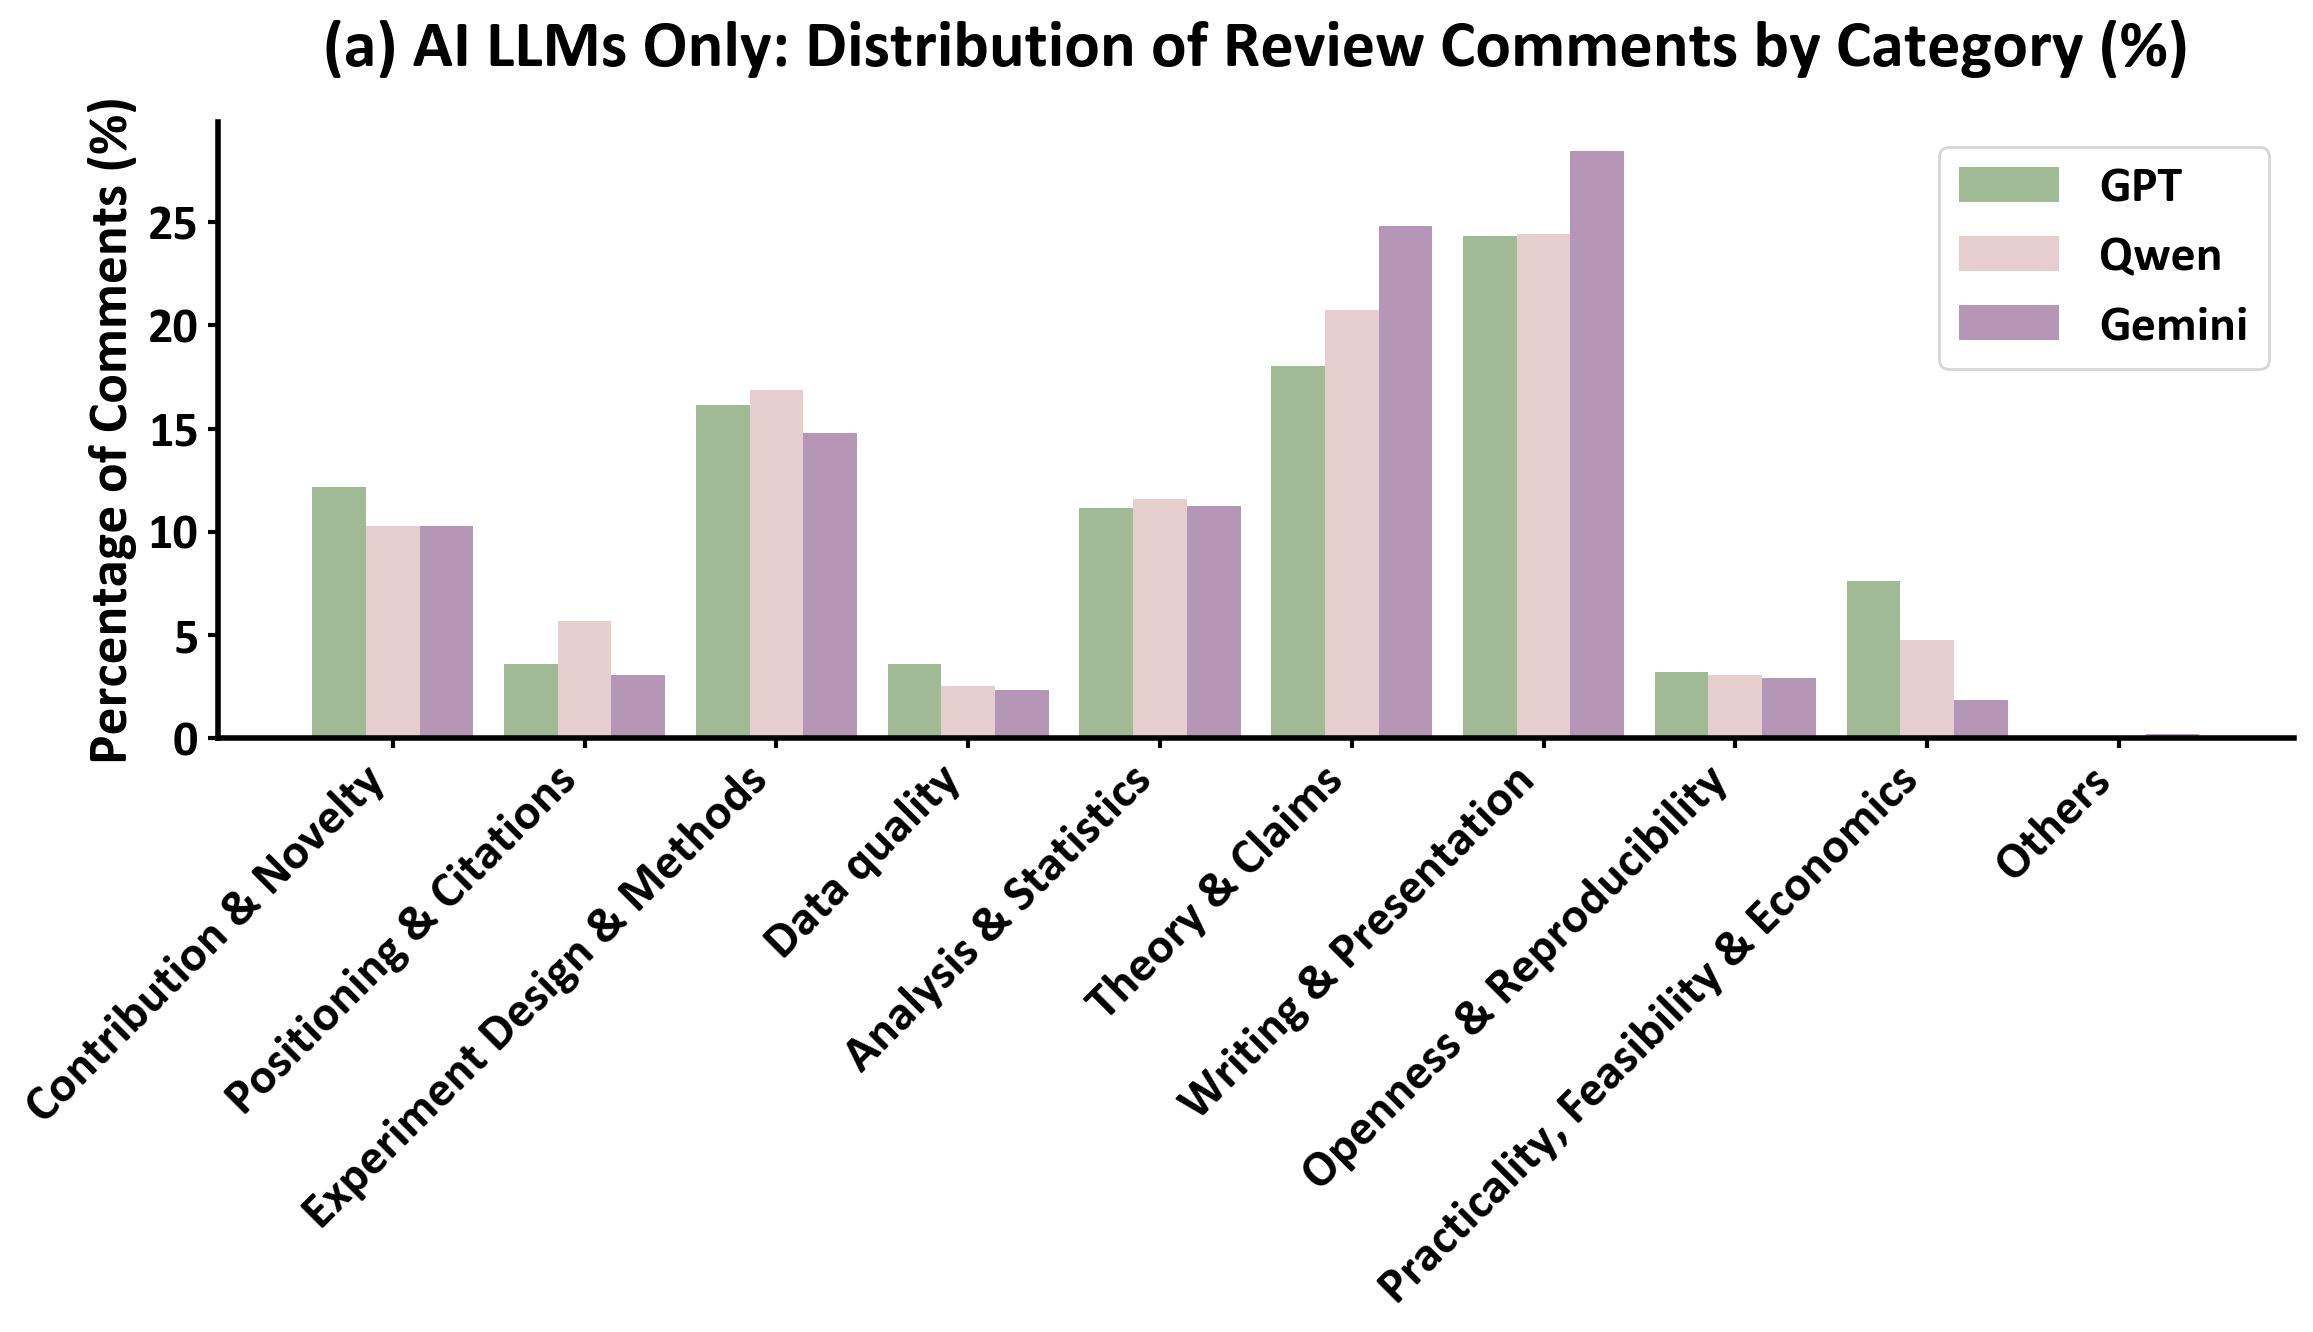

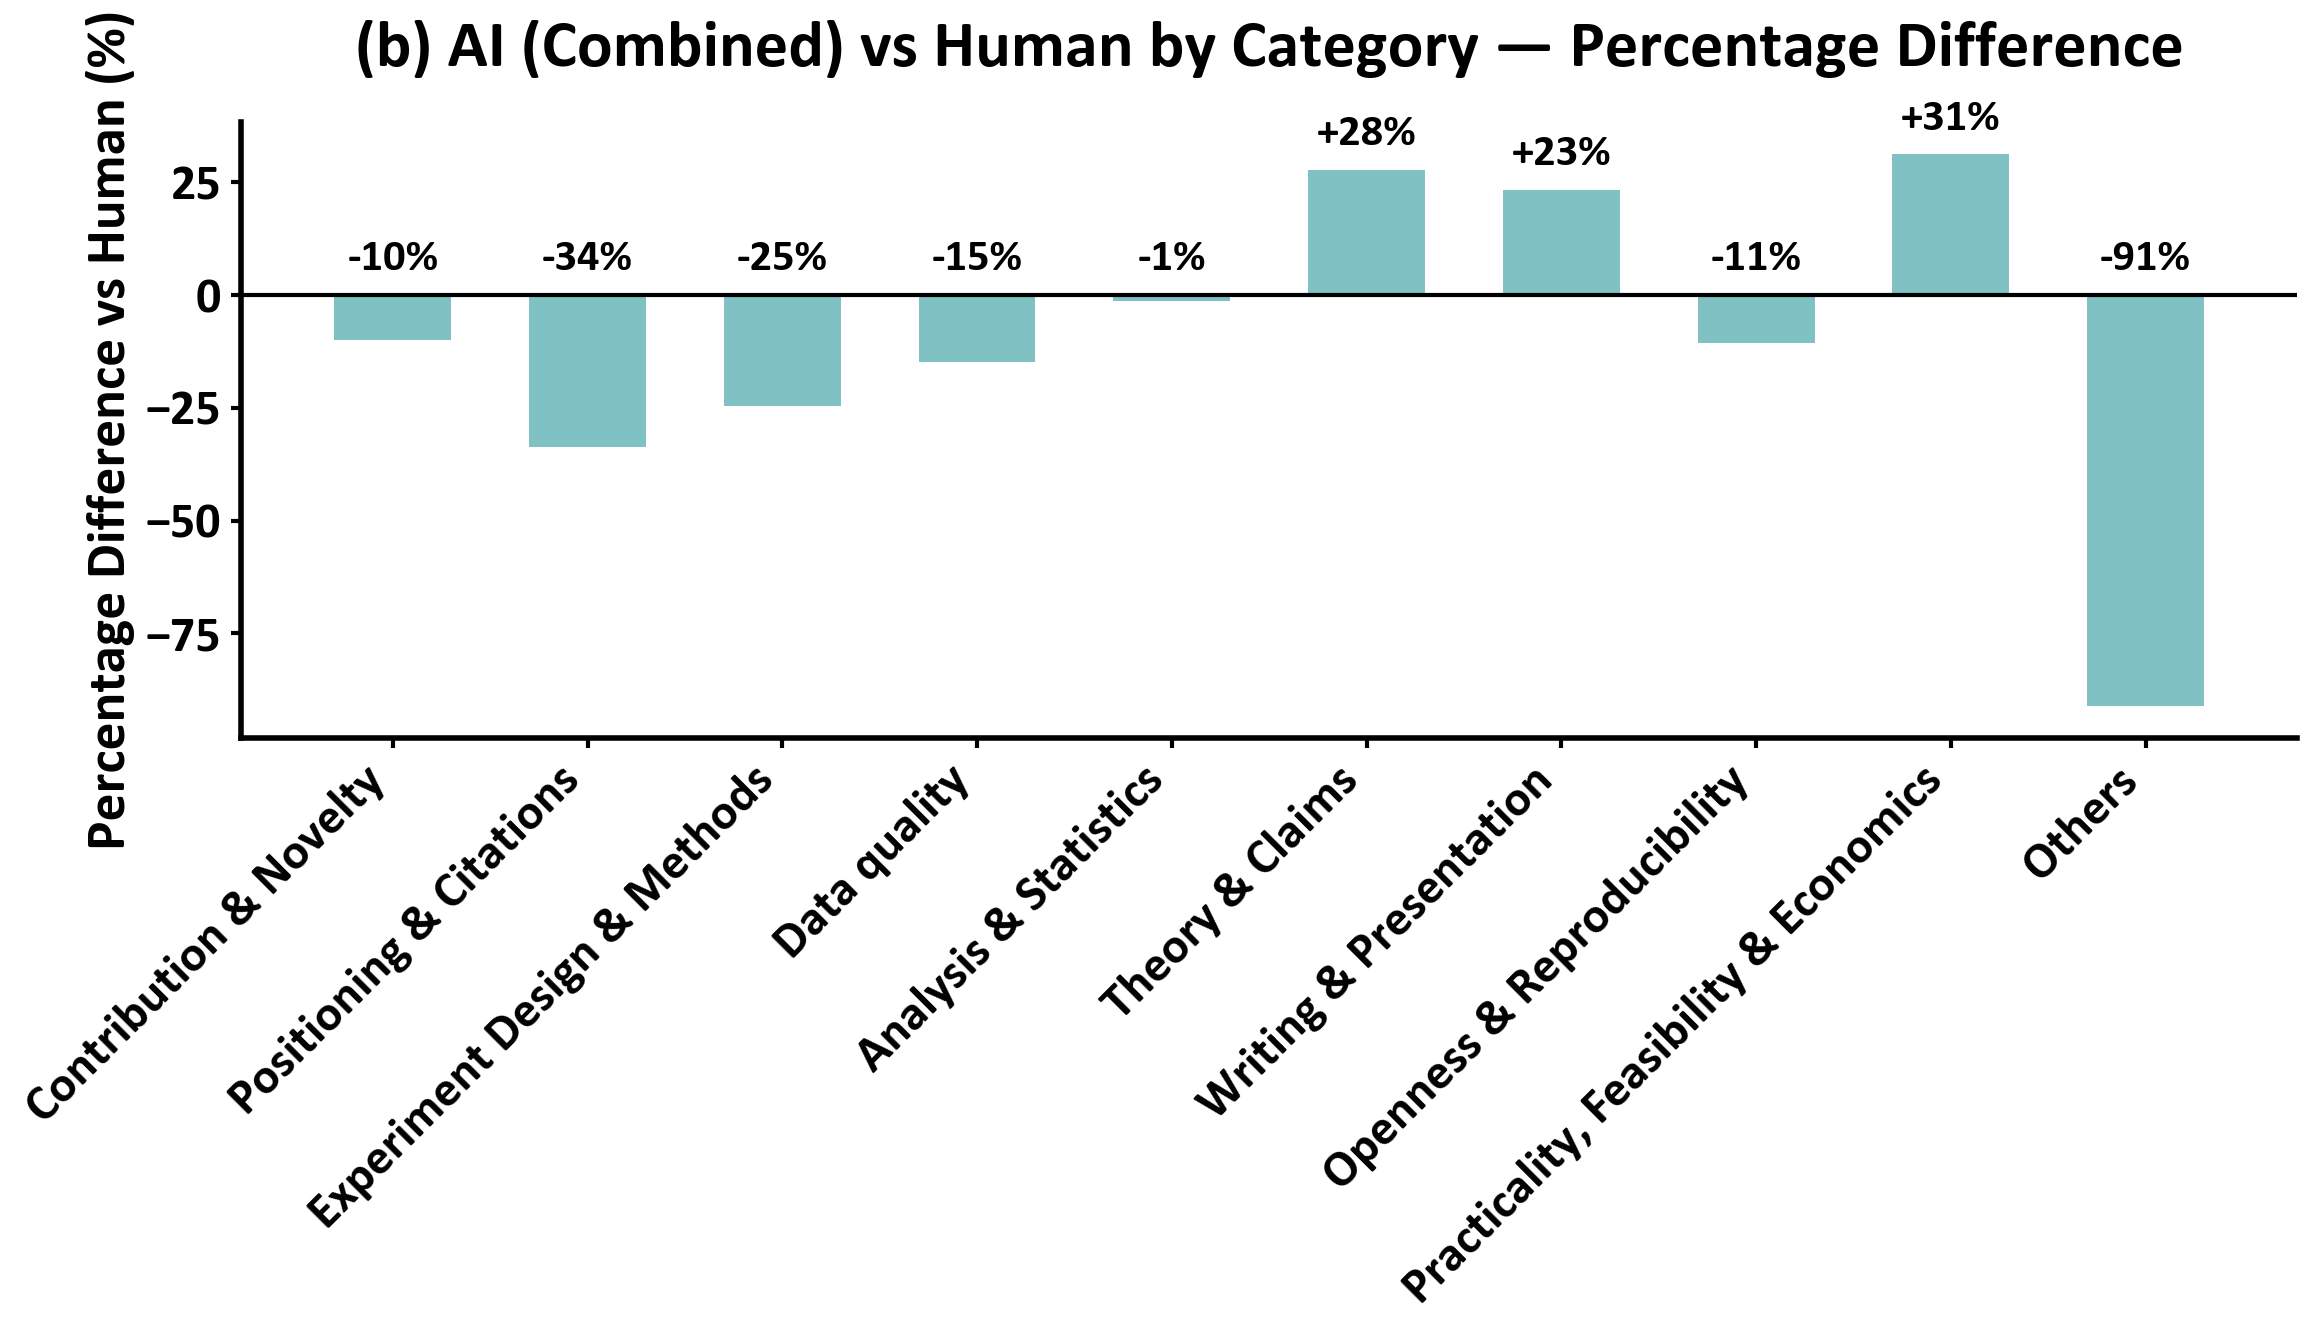

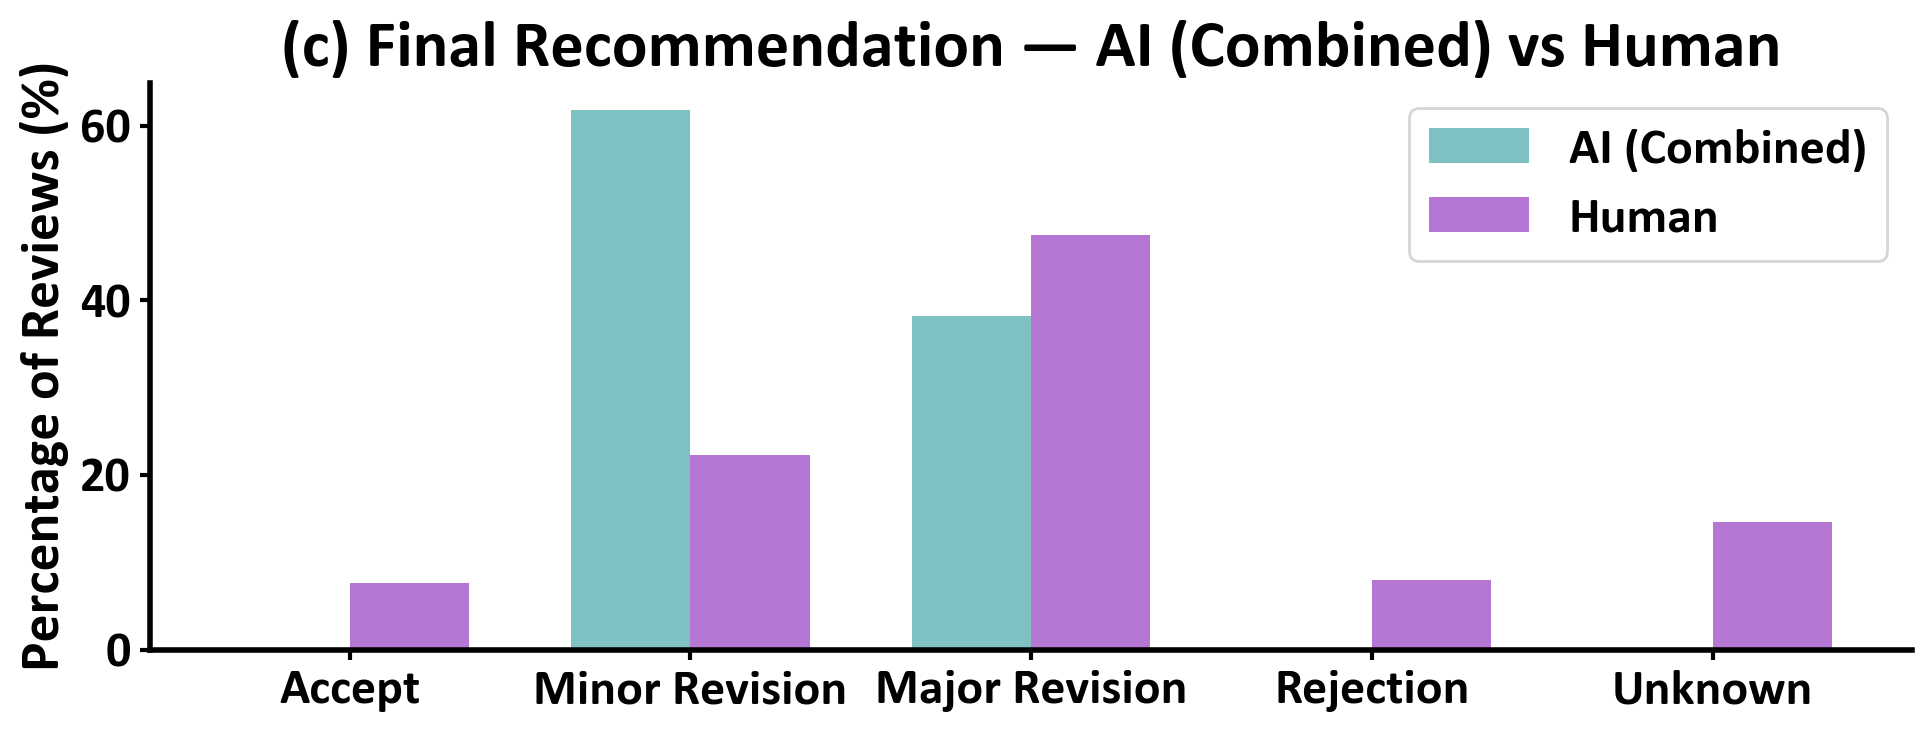


📊 (b) Percentage Difference vs Human by Category
Contribution & Novelty                   :  -9.99%
Positioning & Citations                  : -33.59%
Experiment Design & Methods              : -24.66%
Data quality                             : -14.83%
Analysis & Statistics                    :  -1.39%
Theory & Claims                          : +27.81%
Writing & Presentation                   : +23.32%
Openness & Reproducibility               : -10.58%
Practicality, Feasibility & Economics    : +31.23%
Others                                   : -91.07%

📊 (c) Final Recommendation — Absolute % (AI Combined vs Human)
Decision                 AI %    Human %
----------------------------------------
Accept                  0.00%      7.64%
Minor Revision         61.83%     22.26%
Major Revision         38.17%     47.51%
Rejection               0.00%      7.97%
Unknown                 0.00%     14.62%

Saved figures:
 - A_ai_category_percentages.png
 - B_ai_vs_human_pct_diff_by_category.pn

In [13]:
# ================================
# Part 2 (Plotting Only) - Run independently
# Show results for 3 LLMs (GPT, Qwen, Gemini) and Human
# ================================
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns  # ok to keep even if not used heavily
from collections import Counter
import matplotlib as mpl
import numpy as np

# 📌 Use Calibri font globally (falls back if unavailable)
mpl.rcParams['font.family'] = 'Calibri'

# 📌 High DPI for sharper plots
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 300

# 📌 Increase font sizes globally - MUCH BIGGER and BOLD
plt.rcParams['font.size'] = 18          # Base font size (was 14)
plt.rcParams['axes.titlesize'] = 24     # Title font size (was 18)
plt.rcParams['axes.labelsize'] = 20     # Axis label font size (was 16)
plt.rcParams['xtick.labelsize'] = 18    # X-axis tick label font size (was 14)
plt.rcParams['ytick.labelsize'] = 18    # Y-axis tick label font size (was 14)
plt.rcParams['legend.fontsize'] = 18    # Legend font size (was 14)

# 📌 Make all text bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# 📌 Make axis lines thicker
plt.rcParams['axes.linewidth'] = 2.0    # Thicker axis lines
plt.rcParams['xtick.major.width'] = 1.5 # Thicker tick marks
plt.rcParams['ytick.major.width'] = 1.5 # Thicker tick marks

# ---------- Load saved results ----------
possible_paths = [
    "synbio_review_classification_results.json",  # global summary saved by analysis step
    "review_classification_results.json"          # fallback (if run within a single paper folder)
]
results_path = next((p for p in possible_paths if os.path.exists(p)), None)
if not results_path:
    raise FileNotFoundError(
        "No results file found. Expected one of: " + ", ".join(possible_paths)
    )

with open(results_path, "r", encoding="utf-8") as f:
    all_results = json.load(f)

# ---------- Category labels ----------
categories_labels = [
    "1. Contribution & Novelty",
    "2. Positioning & Citations",
    "3. Experiment Design & Methods",
    "4. Data quality",
    "5. Analysis & Statistics",
    "6. Theory & Claims",
    "7. Writing & Presentation",
    "8. Openness & Reproducibility",
    "9. Practicality, Feasibility & Economics",
    "10. Others"
]

# ---------- Initialize counters ----------
gpt_counts = Counter()
qwen_counts = Counter()
gemini_counts = Counter()
human_counts = Counter()

decision_counter_gpt = Counter()
decision_counter_qwen = Counter()
decision_counter_gemini = Counter()
decision_counter_human = Counter()

# ---------- Helper: map reviewer key to group ----------
def group_from_key(key: str):
    k = key.lower()
    if k.startswith("human") or "human" in k:
        return "human"
    if "qwen" in k:
        return "qwen"
    if "gemini" in k:
        return "gemini"
    # Treat any GPT variants as GPT (e.g., gpt-4, gpt-5-chat-latest)
    if "gpt" in k or "chatgpt" in k:
        return "gpt"
    return None

# ---------- Aggregate data ----------
for paper_id, reviews in all_results.items():
    for reviewer_key, data in reviews.items():
        cats = data.get("categories", [])
        rec = data.get("recommendation", "Unknown")
        group = group_from_key(reviewer_key)
        if group == "qwen":
            qwen_counts.update(cats)
            decision_counter_qwen[rec] += 1
        elif group == "gemini":
            gemini_counts.update(cats)
            decision_counter_gemini[rec] += 1
        elif group == "gpt":
            gpt_counts.update(cats)
            decision_counter_gpt[rec] += 1
        elif group == "human":
            human_counts.update(cats)
            decision_counter_human[rec] += 1
        else:
            # Unrecognized key; skip silently
            pass

# ---------- Conversions ----------
def to_percent(counts: Counter):
    total = sum(counts.values())
    return [counts.get(i, 0) / total * 100 if total > 0 else 0 for i in range(1, 11)]

def vals_for(counter: Counter, decision_labels):
    return [counter.get(d, 0) for d in decision_labels]

def to_percentages(vals):
    total = sum(vals)
    return [(v / total * 100) if total > 0 else 0 for v in vals]

# ---------- Compute % by category ----------
qwen_pcts = to_percent(qwen_counts)
gemini_pcts = to_percent(gemini_counts)
gpt_pcts = to_percent(gpt_counts)
human_pcts = to_percent(human_counts)

# =====================================================
# (a) AI-only category distribution (% by category)
# =====================================================
x = np.arange(10)
width = 0.28
colors_a = ['#9FBA95', '#E6CECF', '#B696B6']  # GPT, Qwen, Gemini

plt.figure(figsize=(12, 7))
plt.bar(x - width, gpt_pcts, width, label='GPT', color=colors_a[0])
plt.bar(x,          qwen_pcts, width, label='Qwen', color=colors_a[1])
plt.bar(x + width,  gemini_pcts, width, label='Gemini', color=colors_a[2])

plt.ylabel('Percentage of Comments (%)', fontsize=20, weight='bold')
plt.title('(a) AI LLMs Only: Distribution of Review Comments by Category (%)',
          fontsize=24, weight='bold', pad=20)
plt.xticks(x, [lbl.split(". ", 1)[1] for lbl in categories_labels],
           rotation=45, ha='right', fontsize=18, weight='bold')
plt.legend(fontsize=18, prop={'weight': 'bold'})

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2.0)
ax.spines['bottom'].set_linewidth(2.0)

plt.tight_layout()
plt.savefig("A_ai_category_percentages.png", dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# (b) AI-combined vs Human: percentage difference vs Human
#      ((AI% - Human%) / Human%) * 100  (no absolute value)
#      With +xx% labels ABOVE every bar (including negatives).
# =====================================================
# Combine AI model comment counts, then convert to percentages
ai_combined_counts = Counter()
for c in range(1, 11):
    ai_combined_counts[c] = gpt_counts.get(c, 0) + qwen_counts.get(c, 0) + gemini_counts.get(c, 0)

ai_pcts = to_percent(ai_combined_counts)  # length 10
human_pcts = to_percent(human_counts)     # recompute for clarity

pct_diff_vs_human = []
for ai_pct, h_pct in zip(ai_pcts, human_pcts):
    if h_pct == 0:
        pct_diff_vs_human.append(np.nan)  # avoid division-by-zero
    else:
        pct_diff_vs_human.append((ai_pct - h_pct) / h_pct * 100.0)

plt.figure(figsize=(12, 7))
bars = plt.bar(x, pct_diff_vs_human, width=0.6, color='#80C1C4', label='AI (combined) vs Human')
plt.axhline(0, color='black', linewidth=1.5)

plt.ylabel('Percentage Difference vs Human (%)', fontsize=20, weight='bold')
plt.title('(b) AI (Combined) vs Human by Category — Percentage Difference',
          fontsize=24, weight='bold', pad=20)
plt.xticks(x, [lbl.split(". ", 1)[1] for lbl in categories_labels],
           rotation=45, ha='right', fontsize=18, weight='bold')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2.0)
ax.spines['bottom'].set_linewidth(2.0)

# --- Labels: always place ABOVE the bar's top edge ---
# For positive bars: above their height; for negative bars: above 0 baseline.
# Also add headroom so labels don't clip.
finite_vals = np.array([v for v in pct_diff_vs_human if not np.isnan(v)])
if finite_vals.size == 0:
    y_min, y_max = -1, 1
else:
    y_min = min(finite_vals.min(), 0)
    y_max = max(finite_vals.max(), 0)

pad = max(5, 0.08 * max(abs(y_min), abs(y_max)) if (y_min != 0 or y_max != 0) else 5)
plt.ylim(y_min - pad, y_max + pad)

for rect, diff in zip(bars, pct_diff_vs_human):
    if np.isnan(diff):
        continue  # skip categories where Human % = 0 (no bar)
    height = rect.get_height()
    # The "top" edge of the bar (y) is height if positive, else 0 for negative bars.
    top_edge_y = height if height >= 0 else 0.0
    # Place label a few points above that edge
    ax.annotate(
        f"{diff:+.0f}%",
        xy=(rect.get_x() + rect.get_width() / 2.0, top_edge_y),
        xytext=(0, 6),  # 6 points upward
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=16,
        fontweight='bold',
        clip_on=False
    )

plt.tight_layout()
plt.savefig("B_ai_vs_human_pct_diff_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# (c) Final recommendation — AI combined vs Human (absolute %)
# =====================================================
decision_labels = ["Accept", "Minor Revision", "Major Revision", "Rejection", "Unknown"]

# Combine decision counters for AI
decision_counter_ai = Counter()
for k, v in decision_counter_gpt.items():
    decision_counter_ai[k] += v
for k, v in decision_counter_qwen.items():
    decision_counter_ai[k] += v
for k, v in decision_counter_gemini.items():
    decision_counter_ai[k] += v

vals_ai = vals_for(decision_counter_ai, decision_labels)
vals_human = vals_for(decision_counter_human, decision_labels)

pcts_ai = to_percentages(vals_ai)
pcts_human_rec = to_percentages(vals_human)

x2 = np.arange(len(decision_labels))
width2 = 0.35
colors_c = ['#80C1C4', '#B676D3']  # AI combined, Human

plt.figure(figsize=(10, 4))
plt.bar(x2 - width2/2, pcts_ai, width2, label='AI (Combined)', color=colors_c[0])
plt.bar(x2 + width2/2, pcts_human_rec, width2, label='Human', color=colors_c[1])

plt.ylabel('Percentage of Reviews (%)', fontsize=20, weight='bold')
plt.title('(c) Final Recommendation — AI (Combined) vs Human',
          fontsize=24, weight='bold')
plt.xticks(x2, decision_labels, fontsize=18, weight='bold')
plt.legend(fontsize=18, prop={'weight': 'bold'})

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2.0)
ax.spines['bottom'].set_linewidth(2.0)

plt.tight_layout()
plt.savefig("C_final_recommendation_ai_vs_human_pct.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------- Optional: concise printouts ----------
print("\n" + "="*70)
print("📊 (b) Percentage Difference vs Human by Category")
print("="*70)
for lbl, diff in zip(categories_labels, pct_diff_vs_human):
    label_short = lbl.split(". ", 1)[1]
    if np.isnan(diff):
        print(f"{label_short:<40} :  —  (Human % = 0)")
    else:
        print(f"{label_short:<40} : {diff:+6.2f}%")

print("\n" + "="*70)
print("📊 (c) Final Recommendation — Absolute % (AI Combined vs Human)")
print("="*70)
print(f"{'Decision':<18} {'AI %':>10} {'Human %':>10}")
print("-"*40)
for d, a, h in zip(decision_labels, pcts_ai, pcts_human_rec):
    print(f"{d:<18} {a:>9.2f}% {h:>9.2f}%")

print("\nSaved figures:")
print(" - A_ai_category_percentages.png")
print(" - B_ai_vs_human_pct_diff_by_category.png")
print(" - C_final_recommendation_ai_vs_human_pct.png")


Columns in zero-shot sheet:
['Proposal ID', 'gpt5_t1', 'gpt5_t2', 'gpt5_t3', 'qwen_t1', 'qwen_t2', 'qwen_t3', 'gem_t1', 'gem_t2', 'gem_t3', 'hum_t1', 'hum_t2', 'hum_t3']

Dataset shape: (12, 13)

First few rows:
   Proposal ID  gpt5_t1  gpt5_t2  gpt5_t3  qwen_t1  qwen_t2  qwen_t3  gem_t1  \
0            1        3      3.0      3.5      3.0        3      4.0       4   
1            2        4      3.0      3.5      2.0        4      4.0       4   
2            3        3      4.0      3.5      4.0        3      3.5       3   
3            4        4      4.0      4.0      4.0        4      3.5       4   
4            5        3      3.0      3.5      4.0        3      3.5       3   

   gem_t2  gem_t3  hum_t1  hum_t2  hum_t3  
0     4.0     4.0     4.0     2.0     2.0  
1     4.0     3.0     2.5     2.5     2.5  
2     3.0     4.0     2.0     2.0     3.0  
3     2.5     3.0     3.0     3.5     1.0  
4     3.0     2.5     1.0     1.0     2.0  

Proposal ID column: Proposal ID
Reviewer c

C:\Users\shawn\AppData\Local\Temp\ipykernel_40588\670252910.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


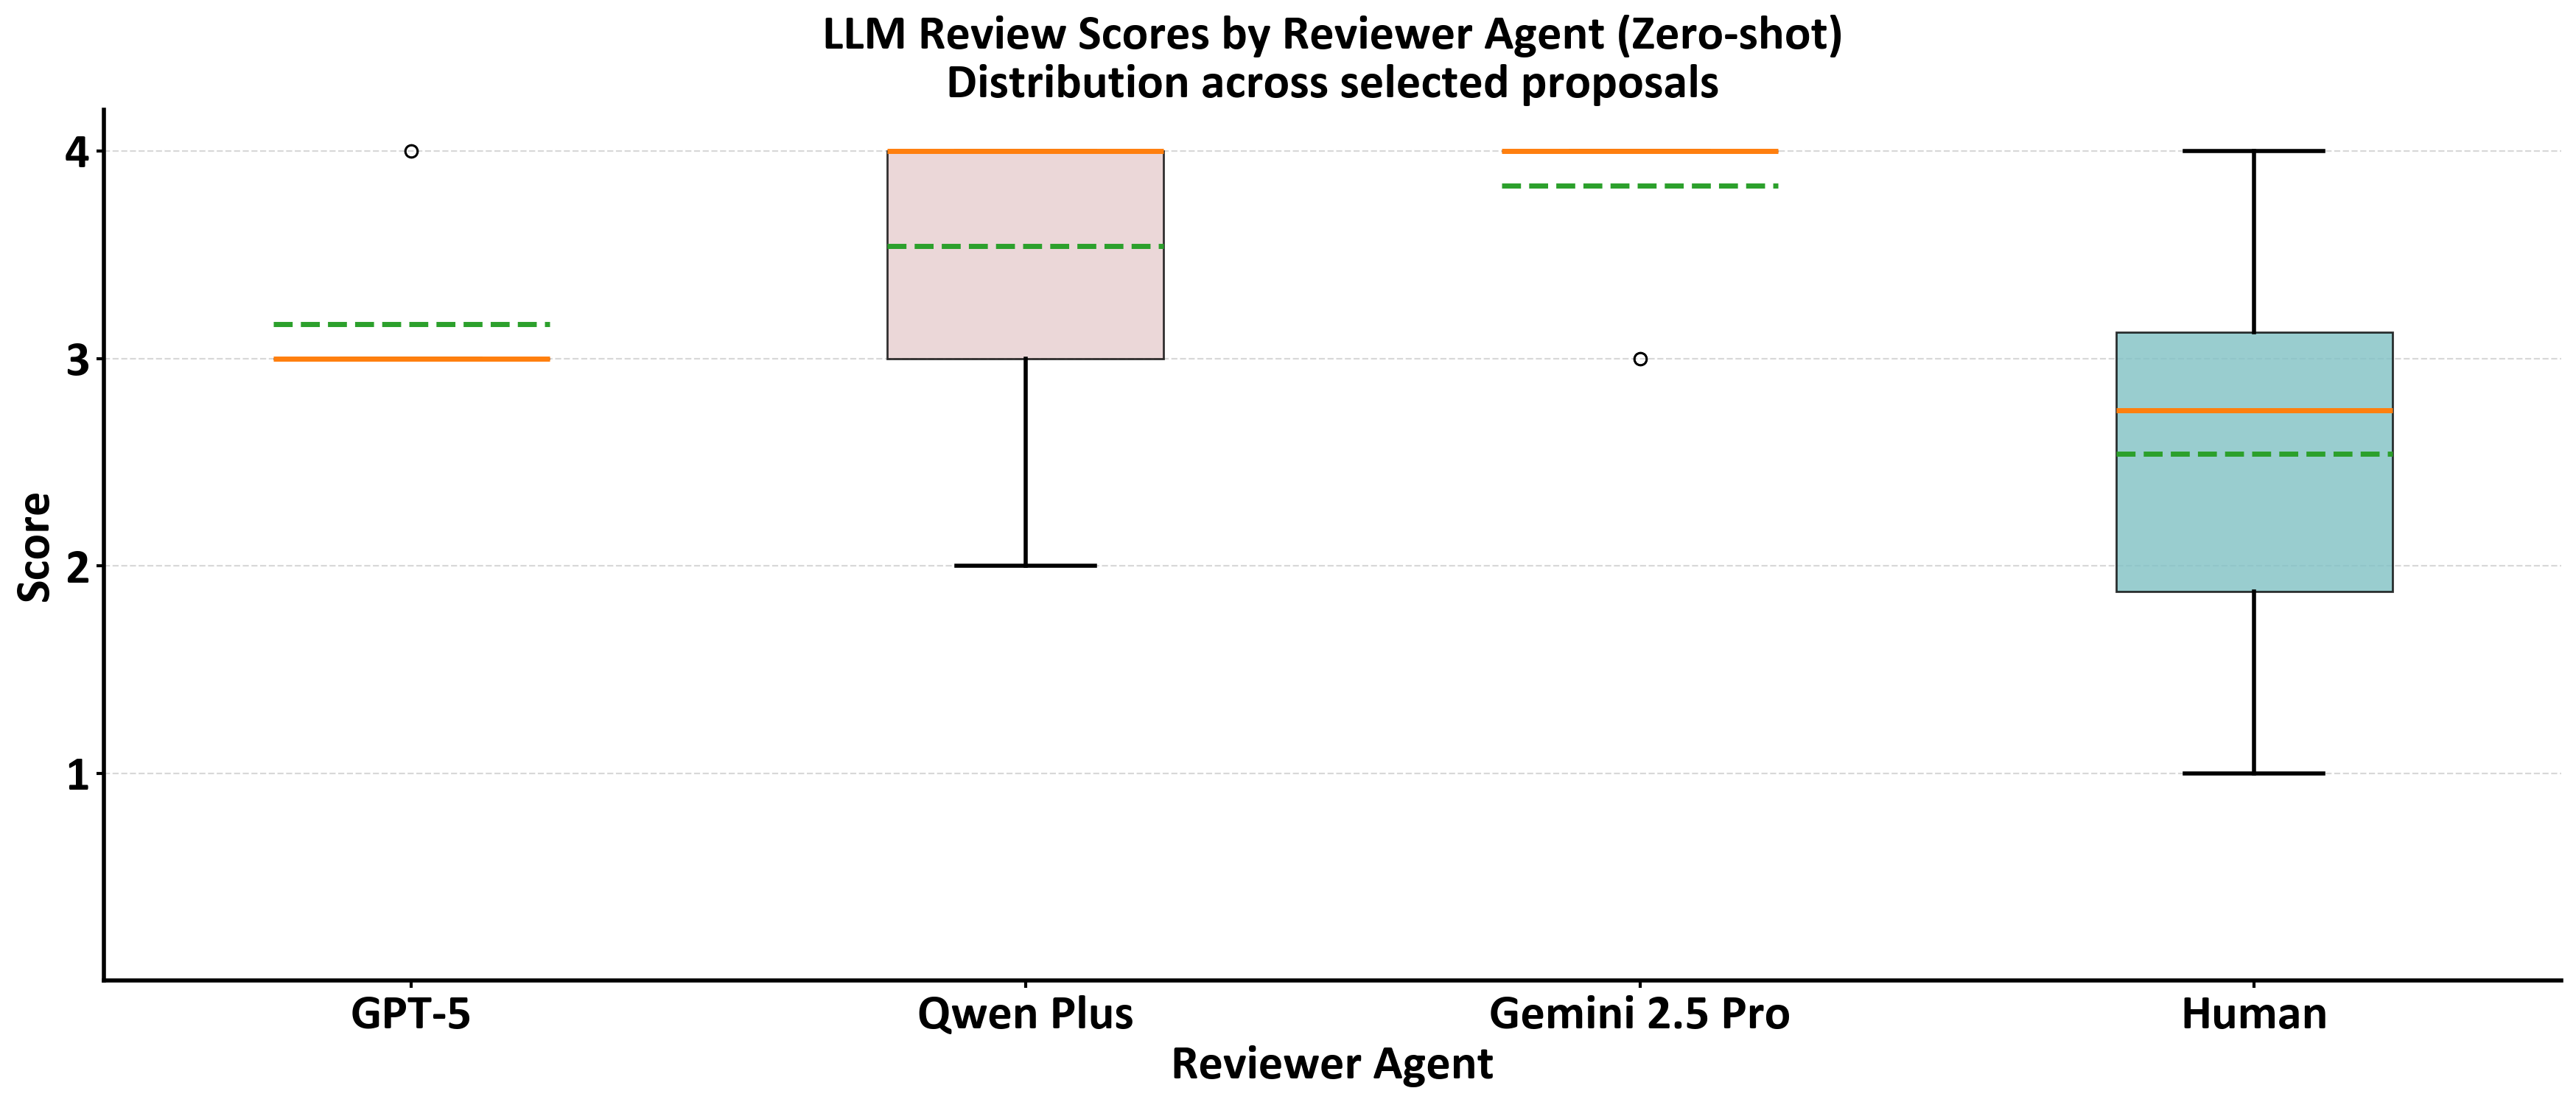


Summary Statistics (across selected proposals):
GPT-5: Overall Mean=3.17, Overall Std (all scores)=0.39, Std across proposal means=0.39, N scores=12, N proposals with data=12
Qwen Plus: Overall Mean=3.54, Overall Std (all scores)=0.72, Std across proposal means=0.72, N scores=12, N proposals with data=12
Gemini 2.5 Pro: Overall Mean=3.83, Overall Std (all scores)=0.39, Std across proposal means=0.39, N scores=12, N proposals with data=12
Human: Overall Mean=2.54, Overall Std (all scores)=1.05, Std across proposal means=1.05, N scores=12, N proposals with data=12


In [16]:
# Box plot for grant results from zero-shot sheet (std, not SEM)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set font properties for consistency - BIGGER FONTS
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 24
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 24
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['axes.titleweight'] = 'bold'

# Palette (kept for visual consistency)
colors = ['#9FBA95', '#E6CECF', '#B696B6', '#80C1C4']

# Load data from grant_results.xlsx, zero-shot sheet
grant_path = Path("grant_results.xlsx")
if not grant_path.exists():
    print(f"File not found: {grant_path}")
    print("Available files:")
    for f in Path(".").glob("*.xlsx"):
        print(f"  {f}")
else:
    # Read the zero-shot sheet
    df_grants = pd.read_excel(grant_path, sheet_name="zero-shot")

    print("Columns in zero-shot sheet:")
    print(df_grants.columns.tolist())
    print(f"\nDataset shape: {df_grants.shape}")
    print("\nFirst few rows:")
    print(df_grants.head())

    # Find proposal ID column (flexible naming)
    proposal_id_col = None
    for col in df_grants.columns:
        if 'proposal' in col.lower() and 'id' in col.lower():
            proposal_id_col = col
            break

    if proposal_id_col is None:
        # Try other common names
        for col in df_grants.columns:
            if col.lower() in ['id', 'proposal', 'grant_id', 'application_id']:
                proposal_id_col = col
                break

    # Find reviewer agent columns with specific prefixes
    reviewer_prefixes = ['gpt5', 'qwen', 'gem', 'hum']
    reviewer_cols = []
    reviewer_labels = []

    for prefix in reviewer_prefixes:
        for col in df_grants.columns:
            if col.lower().startswith(prefix.lower()):
                reviewer_cols.append(col)
                # Clean labels for legend / x-axis
                if prefix == 'gpt5':
                    reviewer_labels.append('GPT-5')
                elif prefix == 'qwen':
                    reviewer_labels.append('Qwen Plus')
                elif prefix == 'gem':
                    reviewer_labels.append('Gemini 2.5 Pro')
                elif prefix == 'hum':
                    reviewer_labels.append('Human')
                break

    print(f"\nProposal ID column: {proposal_id_col}")
    print(f"Reviewer columns found: {reviewer_cols}")
    print(f"Reviewer labels: {reviewer_labels}")

    if proposal_id_col and reviewer_cols:
        # Get unique proposal IDs (first 12 to mirror your original logic)
        proposal_ids = df_grants[proposal_id_col].unique()[:12]
        print(f"\nUsing proposal IDs: {proposal_ids}")

        # Subset the dataframe to the selected proposals
        df_sub = df_grants[df_grants[proposal_id_col].isin(proposal_ids)]

        # Gather all individual scores per reviewer across the selected proposals
        scores_by_reviewer = []
        for reviewer_col in reviewer_cols:
            col_scores = pd.to_numeric(df_sub[reviewer_col], errors='coerce').dropna().tolist()
            scores_by_reviewer.append(col_scores)

        # Filter out reviewers that ended up with no data
        valid_indices = [i for i, s in enumerate(scores_by_reviewer) if len(s) > 0]
        if not valid_indices:
            print("No valid numeric scores found for the selected proposals.")
        else:
            reviewer_labels = [reviewer_labels[i] for i in valid_indices]
            reviewer_cols = [reviewer_cols[i] for i in valid_indices]
            scores_by_reviewer = [scores_by_reviewer[i] for i in valid_indices]

            # Create a box plot across reviewer agents
            fig, ax = plt.subplots(figsize=(18, 8))

            # Matplotlib boxplot
            bp = ax.boxplot(
                scores_by_reviewer,
                labels=reviewer_labels,
                patch_artist=True,
                showmeans=True,
                meanline=True
            )

            # Color boxes for readability (optional aesthetics)
            for patch, c in zip(bp['boxes'], colors):
                patch.set_facecolor(c)
                patch.set_alpha(0.8)

            # Style medians/means/whiskers
            for median in bp['medians']:
                median.set_linewidth(2.5)
            for mean in bp['means']:
                mean.set_linewidth(2.5)
            for whisker in bp['whiskers']:
                whisker.set_linewidth(2)
            for cap in bp['caps']:
                cap.set_linewidth(2)

            # Customize axes
            ax.set_xlabel('Reviewer Agent')
            ax.set_ylabel('Score')
            ax.set_title('LLM Review Scores by Reviewer Agent (Zero-shot)\nDistribution across selected proposals')
            ax.grid(True, axis='y', linestyle='--', alpha=0.3, color='gray')

            # Y-axis ticks fixed to 1–4 range (adjust if your data differs)
            ax.set_yticks([1, 2, 3, 4])
            ax.set_ylim(bottom=0, top=4.2)

            # Spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_linewidth(2)
            ax.spines['left'].set_linewidth(2)

            plt.tight_layout()
            plt.savefig('grant_reviewer_boxplot.png', dpi=300, bbox_inches='tight')
            plt.show()

            # ---- Summary statistics (using Standard Deviation, not SEM) ----
            print("\nSummary Statistics (across selected proposals):")
            for label, col, scores in zip(reviewer_labels, reviewer_cols, scores_by_reviewer):
                scores_array = np.array(scores)
                overall_mean = np.mean(scores_array)
                overall_std = np.std(scores_array, ddof=1) if len(scores_array) > 1 else 0.0  # sample std

                # Also compute per-proposal means for that reviewer (then std across proposals)
                proposal_means = []
                for pid in proposal_ids:
                    s = pd.to_numeric(
                        df_sub.loc[df_sub[proposal_id_col] == pid, col],
                        errors='coerce'
                    ).dropna().values
                    if len(s) > 0:
                        proposal_means.append(np.mean(s))

                std_across_proposals = (
                    np.std(proposal_means, ddof=1) if len(proposal_means) > 1 else 0.0
                )

                print(
                    f"{label}: "
                    f"Overall Mean={overall_mean:.2f}, Overall Std (all scores)={overall_std:.2f}, "
                    f"Std across proposal means={std_across_proposals:.2f}, "
                    f"N scores={len(scores_array)}, N proposals with data={len(proposal_means)}"
                )
    else:
        print(f"Missing required columns:")
        if not proposal_id_col:
            print("- No proposal ID column found")
        if not reviewer_cols:
            print("- No reviewer agent columns found")
        print(f"Available columns: {df_grants.columns.tolist()}")
